<a href="https://colab.research.google.com/github/202160486-raque/practica_repo/blob/main/Actividad_final_inquilinos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Hábitos y Estilos de Vida de Inquilinos
##### Este proyecto tiene como propósito analizar los hábitos, rutinas y preferencias de un grupo de inquilinos, con el fin de comprender cómo distintos factores ( como el horario de actividad, la alimentación, los intereses culturales o las costumbres sociales) se relacionan entre sí y definen diferentes perfiles de estilo de vida.




#### **Importacion librerías**

In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#####**Limpieza y preparación de los datos**

In [ ]:
#cargar el conjunto de datos

data = pd.read_csv('ds_inquilinos.csv')

#  Corrección de errores de codificación
data.replace("ma√±ana", "mañana", inplace=True)

# Estandarización de respuestas
data = data.apply(lambda x: x.str.lower() if x.dtype == "object" else x)

# Normalizamos las respuestas sí/no
data.replace({"si": "sí", "no ": "no", " s": "sí"}, inplace=True)

# Revisión de valores únicos por columna
print("Valores únicos por variable:\n")
for col in data.columns:
    print(f"{col}: {data[col].unique()}")



Valores únicos por variable:

id_inquilino: [    1     2     3 ... 11998 11999 12000]
horario: ['noche' 'mañana']
ritmo: ['nocturno' 'madrugador']
animacion: ['sí' 'no']
nivel_educativo: ['secundaria' 'universitaria' 'primaria']
cine: ['sí' 'no']
leer : ['no' 'sí']
deporte : ['no' 'sí']
mascotas: ['con mascotas' 'sin mascotas']
comida: ['pedir comida' 'cocinar']
dieta: ['sí' 'no']
fumador: ['sí' 'no']
visitas: ['sí' 'no']
orden: ['relajada' 'ordenada']
musica_tipo: ['reggaeton' 'pop' 'rock' 'clasica']
musica_alta: ['no' 'sí']
plan_perfecto: ['casa' 'salir']
instrumento: ['sí' 'no']


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id_inquilino     12000 non-null  int64 
 1   horario          12000 non-null  object
 2   ritmo            12000 non-null  object
 3   animacion        12000 non-null  object
 4   nivel_educativo  12000 non-null  object
 5   cine             12000 non-null  object
 6   leer             12000 non-null  object
 7   deporte          12000 non-null  object
 8   mascotas         12000 non-null  object
 9   comida           12000 non-null  object
 10  dieta            12000 non-null  object
 11  fumador          12000 non-null  object
 12  visitas          12000 non-null  object
 13  orden            12000 non-null  object
 14  musica_tipo      12000 non-null  object
 15  musica_alta      12000 non-null  object
 16  plan_perfecto    12000 non-null  object
 17  instrumento      12000 non-null

In [ ]:
# Verificación de duplicados
duplicados = data.duplicated().sum()
print(f"\nRegistros duplicados: {duplicados}")





Registros duplicados: 0


In [ ]:
# Revisión nulos
print("\n Valores nulos restantes:")
print(data.isnull().sum())



 Valores nulos restantes:
id_inquilino       0
horario            0
ritmo              0
animacion          0
nivel_educativo    0
cine               0
leer               0
deporte            0
mascotas           0
comida             0
dieta              0
fumador            0
visitas            0
orden              0
musica_tipo        0
musica_alta        0
plan_perfecto      0
instrumento        0
dtype: int64


In [ ]:
data.columns = data.columns.str.strip()

# Convertir todos los nombres a minúsculas (opcional, para consistencia)
data.columns = data.columns.str.lower()


In [ ]:
# Confirmamos que las categorías están limpias ---
print("\n Limpieza completada. Vista previa:")
display(data.head())


 Limpieza completada. Vista previa:


,id_inquilino,horario,ritmo,animacion,nivel_educativo,cine,leer,deporte,mascotas,comida,dieta,fumador,visitas,orden,musica_tipo,musica_alta,plan_perfecto,instrumento
0,1,noche,nocturno,sí,secundaria,sí,no,no,con mascotas,pedir comida,sí,sí,sí,relajada,reggaeton,no,casa,sí
1,2,noche,nocturno,no,secundaria,no,no,no,con mascotas,pedir comida,no,sí,sí,relajada,reggaeton,sí,casa,sí
2,3,noche,madrugador,no,universitaria,no,no,sí,con mascotas,pedir comida,no,sí,no,ordenada,pop,no,casa,no
3,4,noche,nocturno,no,universitaria,sí,sí,no,con mascotas,pedir comida,no,no,sí,relajada,rock,sí,casa,sí
4,5,mañana,nocturno,sí,universitaria,no,no,no,sin mascotas,cocinar,no,no,no,relajada,pop,no,casa,no


En esta etapa se realiza una limpieza integral de las respuestas.
Se corrigen errores de codificación como “ma√±ana” = “mañana”, se estandarizan respuestas para evitar ambigüedad (“si”, “sí”, “Si”), y se revisa la integridad general de los registros.

##### **Análisis exploratorio de los inquilinos**

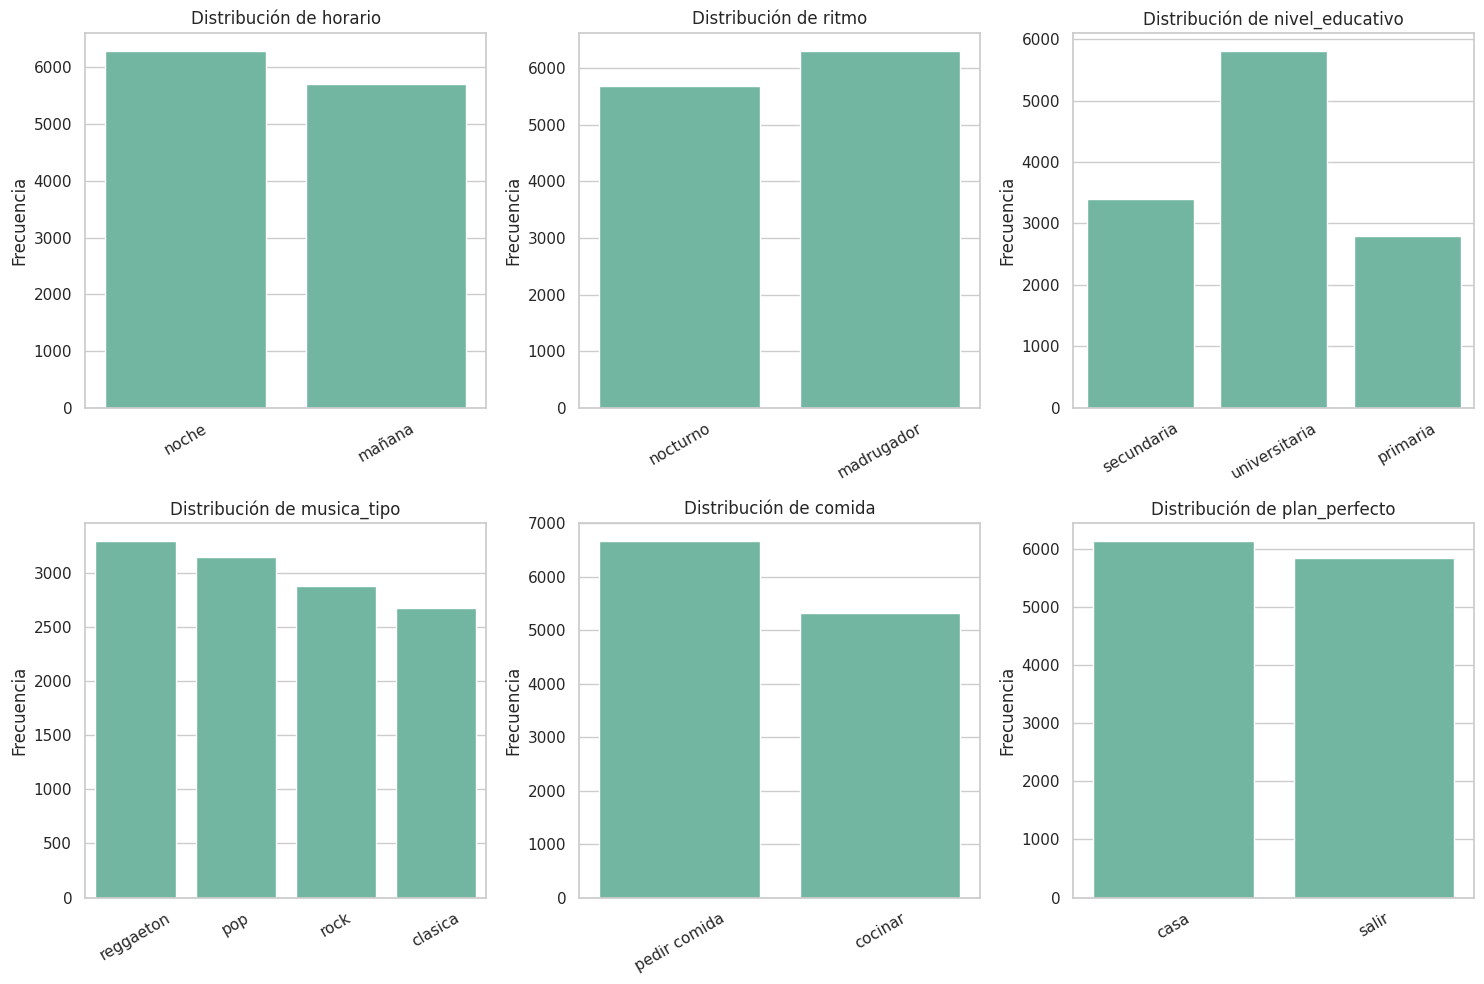

In [ ]:
# Configuración general de estilo
sns.set(style="whitegrid", palette="Set2")

# Cantidad de respuestas por cada categoría en algunas variables clave
variables_clave = ['horario', 'ritmo', 'nivel_educativo', 'musica_tipo', 'comida', 'plan_perfecto']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(variables_clave):
    sns.countplot(data=data, x=col, ax=axes[i])
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
# Conteo de valores por cada variable categórica
cat_cols = data.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\n {col.upper()}:\n", data[col].value_counts(normalize=True).round(2) * 100)



 HORARIO:
 horario
noche     52.0
mañana    48.0
Name: proportion, dtype: float64

 RITMO:
 ritmo
madrugador    53.0
nocturno      47.0
Name: proportion, dtype: float64

 ANIMACION:
 animacion
sí    52.0
no    48.0
Name: proportion, dtype: float64

 NIVEL_EDUCATIVO:
 nivel_educativo
universitaria    48.0
secundaria       28.0
primaria         23.0
Name: proportion, dtype: float64

 CINE:
 cine
no    50.0
sí    50.0
Name: proportion, dtype: float64

 LEER:
 leer
no    54.0
sí    46.0
Name: proportion, dtype: float64

 DEPORTE:
 deporte
sí    54.0
no    46.0
Name: proportion, dtype: float64

 MASCOTAS:
 mascotas
con mascotas    53.0
sin mascotas    47.0
Name: proportion, dtype: float64

 COMIDA:
 comida
pedir comida    56.0
cocinar         44.0
Name: proportion, dtype: float64

 DIETA:
 dieta
no    50.0
sí    50.0
Name: proportion, dtype: float64

 FUMADOR:
 fumador
no    51.0
sí    49.0
Name: proportion, dtype: float64

 VISITAS:
 visitas
sí    53.0
no    47.0
Name: proportion, dtype: 

Columnas binarias detectadas: ['animacion', 'cine', 'leer', 'deporte', 'dieta', 'fumador', 'visitas', 'musica_alta', 'instrumento']


/tmp/ipython-input-500553424.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_bin[col] = data_bin[col].replace({'sí': 1, 'si': 1, 'no': 0})
/tmp/ipython-input-500553424.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_bin[col] = data_bin[col].replace({'sí': 1, 'si': 1, 'no': 0})
/tmp/ipython-input-500553424.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the futu

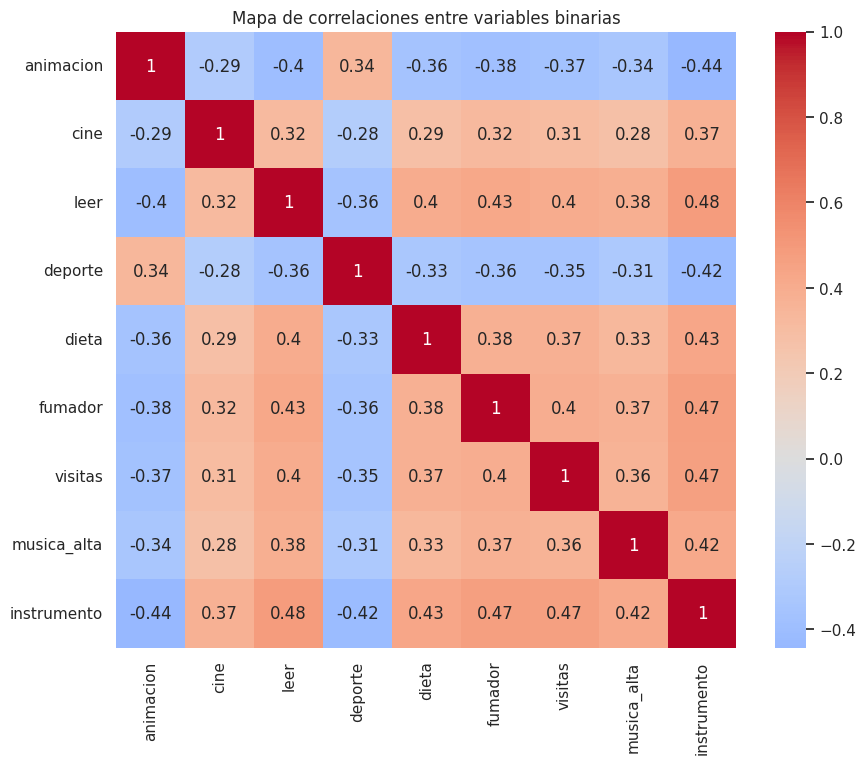

In [ ]:
data_bin = data.copy()

for col in data_bin.columns:
    if data_bin[col].astype(str).str.lower().isin(['sí', 'si', 'no']).any():
        data_bin[col] = data_bin[col].replace({'sí': 1, 'si': 1, 'no': 0})

# Seleccionamos sólo columnas realmente numéricas
binary_cols = [col for col in data_bin.columns if data_bin[col].nunique() == 2 and np.issubdtype(data_bin[col].dtype, np.number)]

# Verificación
print("Columnas binarias detectadas:", binary_cols)

# Calculamos la matriz de correlación
corr_matrix = data_bin[binary_cols].corr()

# Visualización
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True)
plt.title("Mapa de correlaciones entre variables binarias")
plt.show()




El análisis de correlaciones revela que los hábitos de los inquilinos no son independientes, sino que se agrupan en patrones coherentes.
Se identifican relaciones positivas entre actividades sociales y artísticas (como tocar instrumentos, escuchar música alta, fumar y recibir visitas),
y asociaciones negativas entre deporte y hábitos culturales (como leer o tocar instrumentos).
Además, las personas más relajadas tienden a tener estilos de vida menos estructurados y menos sociales.
Estos hallazgos sugieren la existencia de distintos perfiles de comportamiento entre los inquilinos, que podrán agruparse en la siguiente etapa de análisis.

#### **Agrupamiento de perfiles de inquilinos**

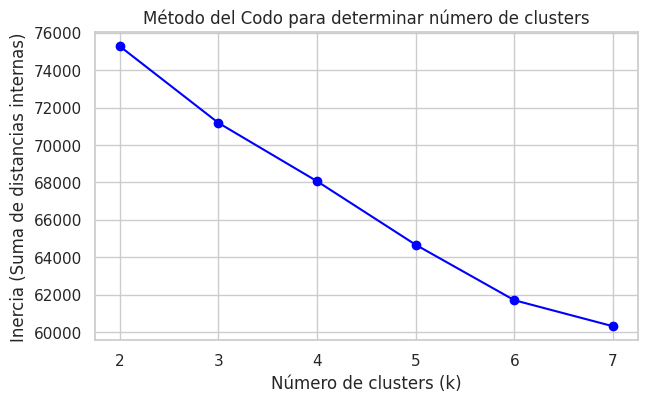

In [ ]:
data_cluster = data_bin.copy()

# Convertimos 'ritmo' a variables (madrugador / nocturno)
data_cluster = pd.get_dummies(data_cluster, columns=['ritmo'], drop_first=True)

# Seleccionamos variables finales
variables_cluster = ['deporte', 'dieta', 'fumador', 'visitas', 'animacion',
                     'musica_alta', 'instrumento', 'leer', 'cine', 'ritmo_nocturno']

X = data_cluster[variables_cluster].astype(float)

# Estandarizamos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
K = range(2, 8)  # probamos entre 2 y 7 grupos

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(7,4))
plt.plot(K, inertias, 'bo-')
plt.title('Método del Codo para determinar número de clusters')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (Suma de distancias internas)')
plt.show()


El método del codo muestra una disminución considerable de la inercia hasta el valor de k = 4, donde la curva comienza a estabilizarse.
Esto sugiere que cuatro grupos (clusters) representan una segmentación adecuada para describir los distintos perfiles de inquilinos,
logrando un equilibrio entre simplicidad y diferenciación entre los grupos.

In [ ]:

# Entrenamiento del modelo K-Means con k=4

kmeans = KMeans(n_clusters=4, random_state=42)
data['cluster'] = kmeans.fit_predict(X_scaled)

# Tamaño de cada grupo
print("Distribución de inquilinos por cluster:")
print(data['cluster'].value_counts())


Distribución de inquilinos por cluster:
cluster
1    5866
2    3829
0    1315
3     990
Name: count, dtype: int64


,deporte,dieta,fumador,visitas,animacion,musica_alta,instrumento,leer,cine,ritmo_nocturno
cluster,,,,,,,,,,
0,0.26,0.74,0.76,0.87,0.27,0.77,0.87,0.00,0.75,0.73
1,0.82,0.20,0.16,0.21,0.82,0.23,0.12,0.13,0.24,0.18
2,0.26,1.00,0.82,0.84,0.21,0.82,0.87,1.00,0.74,0.76
3,0.27,0.00,0.78,0.85,0.27,0.80,0.86,1.00,0.73,0.76


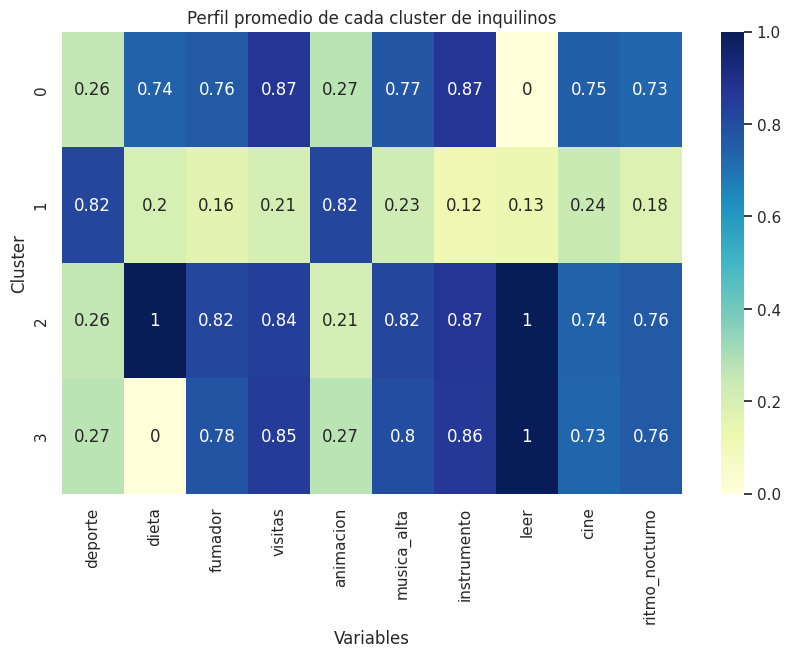

In [ ]:
# Añadimos los clusters al DataFrame procesado
data_cluster['cluster'] = kmeans.labels_

# Calculamos los promedios
perfil_clusters = data_cluster.groupby('cluster')[variables_cluster].mean().round(2)
display(perfil_clusters)

# Visualización del perfil
plt.figure(figsize=(10,6))
sns.heatmap(perfil_clusters, annot=True, cmap='YlGnBu')
plt.title("Perfil promedio de cada cluster de inquilinos")
plt.xlabel("Variables")
plt.ylabel("Cluster")
plt.show()



A partir del análisis, se identificaron cuatro grupos principales de inquilinos,
definidos por sus hábitos de vida, ritmo y preferencias personales:

| Cluster | Descripción general | Rasgos principales| Ritmo      |
| :--------------------------------------- | :------------------------------------------------------- | :------------------------------------ | :--------- |
| **Cluster 0 – “Sociable y relajado”**    | Inquilinos sociables, fuman y disfrutan música y cine.   | Fumadores, sociables, ritmo nocturno. | Nocturno   |
| **Cluster 1 – “Activo y estructurado”**  | Deportistas con rutinas saludables y poca vida social.   | Activos, disciplinados, no fuman.     | Madrugador |
| **Cluster 2 – “Intelectual y hogareño”** | Tranquilos, caseros y aficionados a leer o ver cine.     | Lectores, reservados, algunos fuman.  | Nocturno   |
| **Cluster 3 – “Artístico y nocturno”**   | Creativos y expresivos, disfrutan de música y reuniones. | Músicos, sociables, fumadores.        | Nocturno   |


El modelo K-Means permitió segmentar a los inquilinos en cuatro perfiles claramente diferenciados.
Los factores con mayor influencia en la agrupación fueron el ritmo de vida, la práctica de deporte, los hábitos sociales y el gusto por la música.
Se observa un contraste entre los inquilinos madrugadores y estructurados frente a los nocturnos y sociables, lo que demuestra que el estilo de vida y las preferencias culturales son determinantes para comprender los patrones de convivencia.

#### **Importancia de las variables en la segmentación**

/tmp/ipython-input-2812718371.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancias, palette='Blues_d')


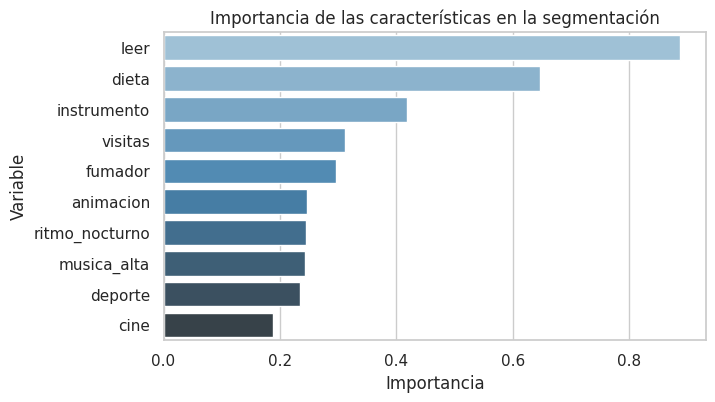

In [ ]:
# Varianza entre clusters para cada variable
importancia_vars = []

for col in variables_cluster:
    var_total = np.var(data_cluster[col])
    var_entre = np.var(perfil_clusters[col])
    importancia = var_entre / var_total if var_total != 0 else 0
    importancia_vars.append(importancia)

#Importancia
importancias = pd.DataFrame({
    'Variable': variables_cluster,
    'Importancia': importancia_vars
}).sort_values(by='Importancia', ascending=False)

# Visualizamos
plt.figure(figsize=(7,4))
sns.barplot(x='Importancia', y='Variable', data=importancias, palette='Blues_d')
plt.title('Importancia de las características en la segmentación')
plt.show()

In [ ]:
print("Importancia de las características en la segmentación:")
display(importancias)

Importancia de las características en la segmentación:


,Variable,Importancia
7,leer,0.887021
1,dieta,0.646717
6,instrumento,0.418236
3,visitas,0.312398
2,fumador,0.296603
4,animacion,0.246443
9,ritmo_nocturno,0.244933
5,musica_alta,0.242844
0,deporte,0.233653
8,cine,0.187702



* Las características que más influyeron en la segmentación fueron leer y dieta, que distinguen los estilos de vida entre inquilinos intelectuales y saludables frente a los más relajados o sociables.
* El modelo K-Means permitió una segmentación coherente de los inquilinos, identificando perfiles desde los disciplinados y madrugadores hasta los artísticos y nocturnos.
* Los resultados muestran que los hábitos personales (lectura, alimentación, música, visitas) son factores clave para comprender la dinámica de convivencia y afinidad entre inquilinos.



El estudio permitió caracterizar distintos perfiles de convivencia mediante un enfoque no supervisado.
Los hallazgos muestran que las preferencias culturales y los hábitos de salud son factores decisivos para segmentar grupos de inquilinos, ofreciendo una base sólida para futuras aplicaciones en convivencia o selección de compañeros de vivienda.